In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# ── font (English only) ────────────────────────────────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False



In [ ]:
# !pip install xlrd

In [5]:
# ══════════════════════════════════════════════════════════════
# STEP 1.  Load Data
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1.  Load Data")
print("=" * 60)

# 로컬 CSV에서 데이터 읽기
df = pd.read_csv("concrete_compressive_strength.csv")

print(df.head())
print(f"\nShape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nDescribe:\n{df.describe().round(2)}")
print(f"\nNull values:\n{df.isnull().sum()}")

STEP 1.  Load Data
   Cement   Slag  FlyAsh  Water  Superplasticizer  CoarseAgg  FineAgg  Age  \
0   540.0    0.0     0.0  162.0               2.5     1040.0    676.0   28   
1   540.0    0.0     0.0  162.0               2.5     1055.0    676.0   28   
2   332.5  142.5     0.0  228.0               0.0      932.0    594.0  270   
3   332.5  142.5     0.0  228.0               0.0      932.0    594.0  365   
4   198.6  132.4     0.0  192.0               0.0      978.4    825.5  360   

    Strength  
0  79.986111  
1  61.887366  
2  40.269535  
3  41.052780  
4  44.296075  

Shape   : (1030, 9)
Columns : ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAgg', 'FineAgg', 'Age', 'Strength']

Describe:
        Cement     Slag   FlyAsh    Water  Superplasticizer  CoarseAgg  \
count  1030.00  1030.00  1030.00  1030.00           1030.00    1030.00   
mean    281.17    73.90    54.19   181.57              6.20     972.92   
std     104.51    86.28    64.00    21.36              5.

In [6]:
# ══════════════════════════════════════════════════════════════
# STEP 2.  EDA
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2.  EDA")
print("=" * 60)

print("\n[Correlation with Strength]")
corr = df.corr()['Strength'].drop('Strength').sort_values(ascending=False)
print(corr.round(3))

print("\n[Skewness]")
print(df.skew().round(3))





STEP 2.  EDA

[Correlation with Strength]
Cement              0.498
Superplasticizer    0.366
Age                 0.329
Slag                0.135
FlyAsh             -0.106
CoarseAgg          -0.165
FineAgg            -0.167
Water              -0.290
Name: Strength, dtype: float64

[Skewness]
Cement              0.510
Slag                0.801
FlyAsh              0.537
Water               0.074
Superplasticizer    0.908
CoarseAgg          -0.040
FineAgg            -0.253
Age                 3.269
Strength            0.417
dtype: float64


In [7]:
# ══════════════════════════════════════════════════════════════
# STEP 3.  Train / Test Split
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3.  Train / Test Split  (80 / 20)")
print("=" * 60)

X = df.drop('Strength', axis=1)
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"Train Strength  mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"Test  Strength  mean={y_test.mean():.2f}, std={y_test.std():.2f}")





STEP 3.  Train / Test Split  (80 / 20)
Train : (824, 8)  (80%)
Test  : (206, 8)  (20%)
Train Strength  mean=35.86, std=16.86
Test  Strength  mean=35.66, std=16.09


In [8]:
# ══════════════════════════════════════════════════════════════
# STEP 4.  Feature Scaling
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4.  Feature Scaling  (StandardScaler)")
print("=" * 60)

# KEY RULE: fit only on training data → transform both sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)        # transform only (no fit!)

print("StandardScaler fitted on X_train only  (data leakage prevention)")
print(f"\nBefore scaling  Cement  mean={X_train['Cement'].mean():.1f}, "
      f"std={X_train['Cement'].std():.1f}")
print(f"After  scaling  Cement  mean={X_train_sc[:,0].mean():.4f}, "
      f"std={X_train_sc[:,0].std():.4f}")
print("\n[Scaling Note]")
print("  Features span very different ranges:")
print(f"  Cement: {df['Cement'].min():.0f}~{df['Cement'].max():.0f} kg/m3")
print(f"  Superp: {df['Superplasticizer'].min():.0f}~"
      f"{df['Superplasticizer'].max():.0f} kg/m3")
print("  Scaling is MANDATORY for Linear Regression coefficient comparison")
print("  Random Forest is scale-invariant, but we scale anyway for consistency")





STEP 4.  Feature Scaling  (StandardScaler)
StandardScaler fitted on X_train only  (data leakage prevention)

Before scaling  Cement  mean=283.4, std=107.5
After  scaling  Cement  mean=-0.0000, std=1.0000

[Scaling Note]
  Features span very different ranges:
  Cement: 102~540 kg/m3
  Superp: 0~32 kg/m3
  Scaling is MANDATORY for Linear Regression coefficient comparison
  Random Forest is scale-invariant, but we scale anyway for consistency


In [9]:
# ══════════════════════════════════════════════════════════════
# STEP 5.  Multiple Linear Regression
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5.  Multiple Linear Regression")
print("=" * 60)

mlr = LinearRegression()
mlr.fit(X_train_sc, y_train)
y_pred_mlr = mlr.predict(X_test_sc)

coef_df = pd.DataFrame({
    'Feature'    : COLUMNS[:-1],
    'Coefficient': mlr.coef_
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept : {mlr.intercept_:.4f}")
print(f"\nCoefficients (on scaled features):")
print(coef_df.to_string(index=False))
print("\n[Interpretation]")
print("  Larger |coef| = stronger linear influence on Strength")
print("  Positive: feature increases Strength")
print("  Negative: feature decreases Strength")





STEP 5.  Multiple Linear Regression

Intercept : 35.8577

Coefficients (on scaled features):
         Feature  Coefficient
          Cement    12.786504
            Slag     9.432883
             Age     7.037787
          FlyAsh     5.255609
         FineAgg     1.947380
Superplasticizer     1.841103
       CoarseAgg     1.400255
           Water    -2.892085

[Interpretation]
  Larger |coef| = stronger linear influence on Strength
  Positive: feature increases Strength
  Negative: feature decreases Strength


In [10]:
# ══════════════════════════════════════════════════════════════
# STEP 6.  Random Forest Regression
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6.  Random Forest Regression")
print("=" * 60)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

# Feature importance (MDI)
fi = pd.Series(rf.feature_importances_, index=COLUMNS[:-1]).sort_values(ascending=False)
print(f"\nFeature Importance (MDI):")
print(fi.round(4))

# Permutation importance (more reliable)
perm = permutation_importance(rf, X_test_sc, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'Feature'   : COLUMNS[:-1],
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=False)
print(f"\nPermutation Importance (test set):")
print(perm_df.round(4).to_string(index=False))





STEP 6.  Random Forest Regression

Feature Importance (MDI):
Age                 0.3328
Cement              0.3245
Water               0.1240
Slag                0.0762
Superplasticizer    0.0589
FineAgg             0.0358
CoarseAgg           0.0280
FlyAsh              0.0198
dtype: float64

Permutation Importance (test set):
         Feature  Importance    Std
             Age      0.8042 0.0423
          Cement      0.5259 0.0496
           Water      0.1975 0.0130
            Slag      0.1734 0.0198
Superplasticizer      0.0941 0.0099
         FineAgg      0.0324 0.0078
       CoarseAgg      0.0093 0.0017
          FlyAsh      0.0036 0.0034


In [11]:
# ══════════════════════════════════════════════════════════════
# STEP 7.  Error Metrics Comparison
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7.  Error Metrics Comparison")
print("=" * 60)

def evaluate(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    adj_r2 = 1 - (ss_res / (len(y_true) - 8 - 1)) / (ss_tot / (len(y_true) - 1))
    mask   = y_true.values != 0
    mape   = np.mean(np.abs((y_true.values[mask] - y_pred[mask])
                             / y_true.values[mask])) * 100
    return {
        'Model'   : name,
        'MSE'     : mse,
        'RMSE'    : rmse,
        'MAE'     : mae,
        'R2'      : r2,
        'Adj_R2'  : adj_r2,
        'MAPE(%)'  : mape
    }

metrics = [
    evaluate(y_test, y_pred_mlr, 'Multiple LR'),
    evaluate(y_test, y_pred_rf,  'Random Forest'),
]
result_df = pd.DataFrame(metrics).set_index('Model')
print(result_df.round(4).to_string())

print("\n[Metric Guide]")
print("  MSE     : Mean Squared Error  (unit: MPa²) — large errors penalized more")
print("  RMSE    : Root MSE            (unit: MPa)  — same scale as target")
print("  MAE     : Mean Absolute Error (unit: MPa)  — robust to outliers")
print("  R²      : Variance explained  (0~1)        — 1 = perfect")
print("  Adj R²  : R² penalized for # of features")
print("  MAPE(%) : % error — scale-independent, intuitive for non-experts")

improvement = (result_df.loc['Multiple LR', 'RMSE'] -
               result_df.loc['Random Forest', 'RMSE'])
print(f"\n>>> Random Forest RMSE improvement over Multiple LR : "
      f"{improvement:.2f} MPa")
print(f">>> This reflects the STRONG NON-LINEAR relationships in concrete data.")





STEP 7.  Error Metrics Comparison
                   MSE    RMSE     MAE      R2  Adj_R2  MAPE(%)
Model                                                          
Multiple LR    95.9755  9.7967  7.7454  0.6275  0.6124  29.2763
Random Forest  30.8463  5.5539  3.7813  0.8803  0.8754  12.3793

[Metric Guide]
  MSE     : Mean Squared Error  (unit: MPa²) — large errors penalized more
  RMSE    : Root MSE            (unit: MPa)  — same scale as target
  MAE     : Mean Absolute Error (unit: MPa)  — robust to outliers
  R²      : Variance explained  (0~1)        — 1 = perfect
  Adj R²  : R² penalized for # of features
  MAPE(%) : % error — scale-independent, intuitive for non-experts

>>> Random Forest RMSE improvement over Multiple LR : 4.24 MPa
>>> This reflects the STRONG NON-LINEAR relationships in concrete data.



STEP 8.  Visualization — 6 figures


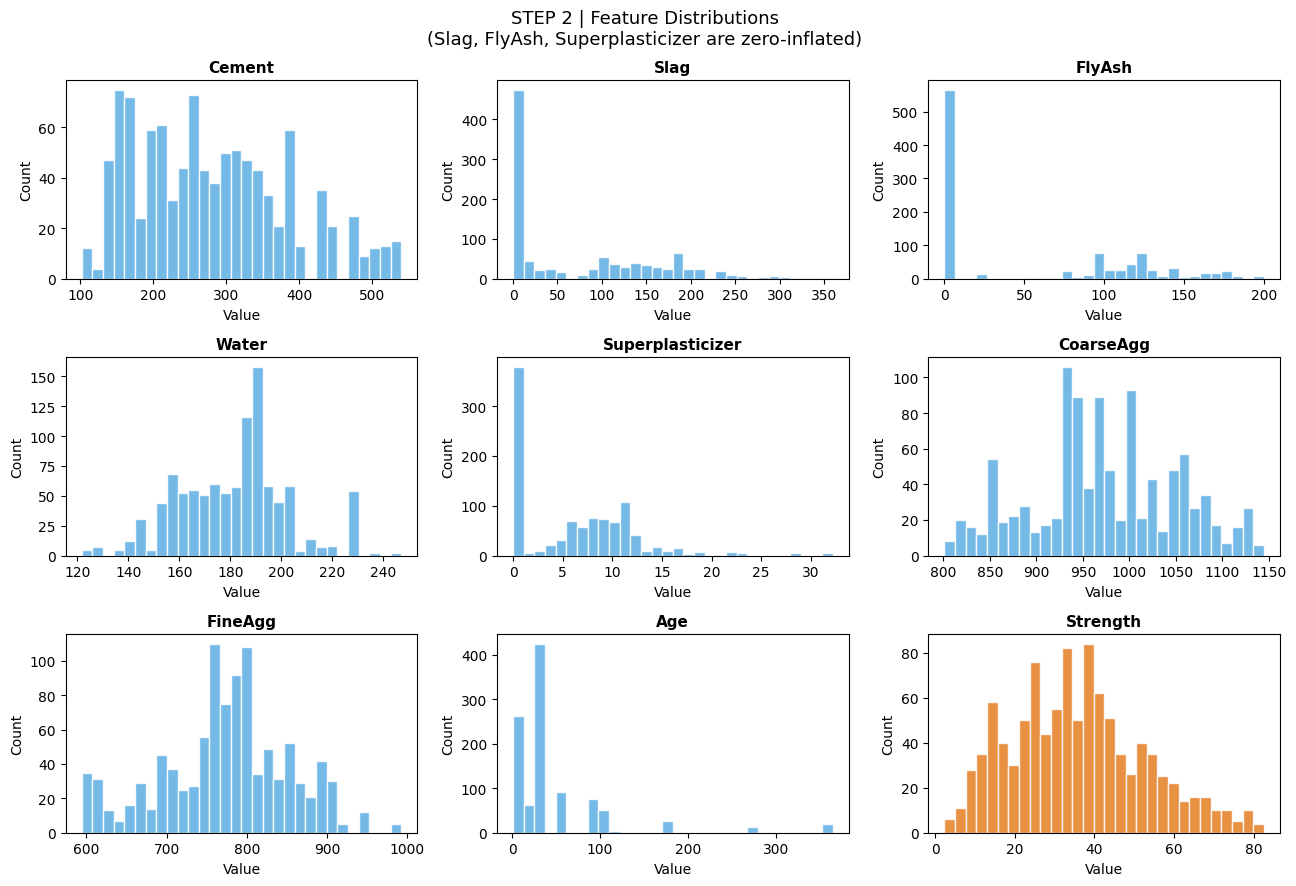

fig1 saved — Feature distributions


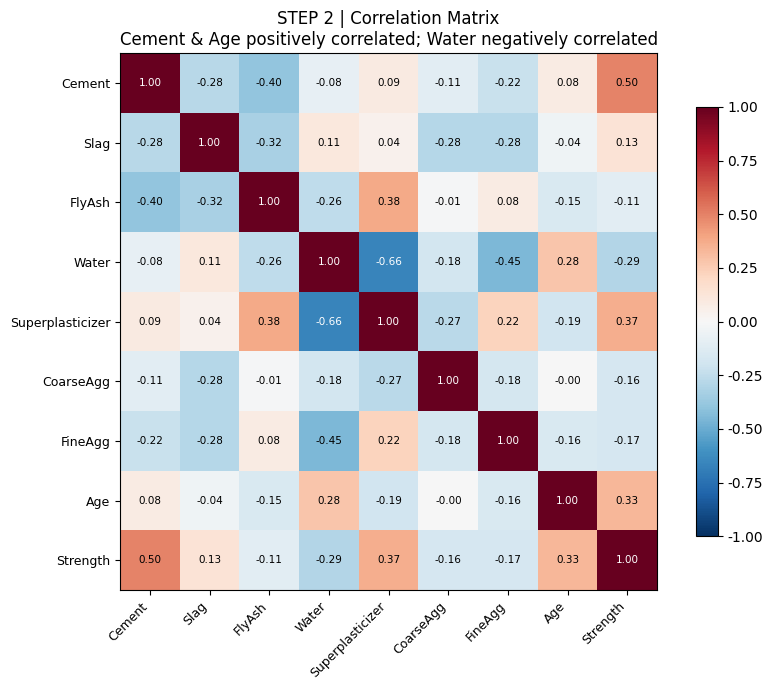

fig2 saved — Correlation heatmap


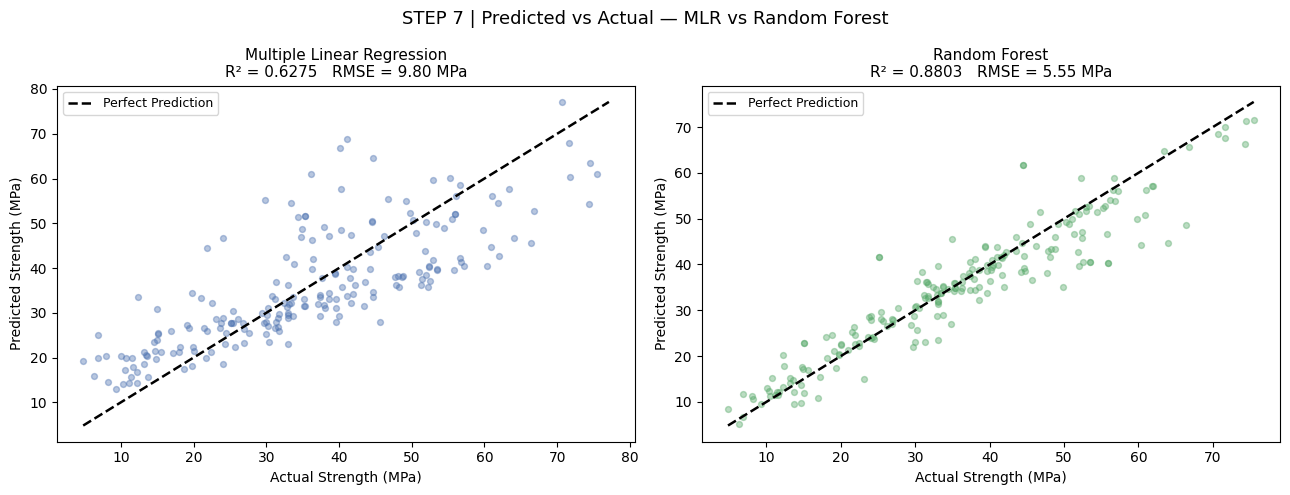

fig3 saved — Predicted vs Actual


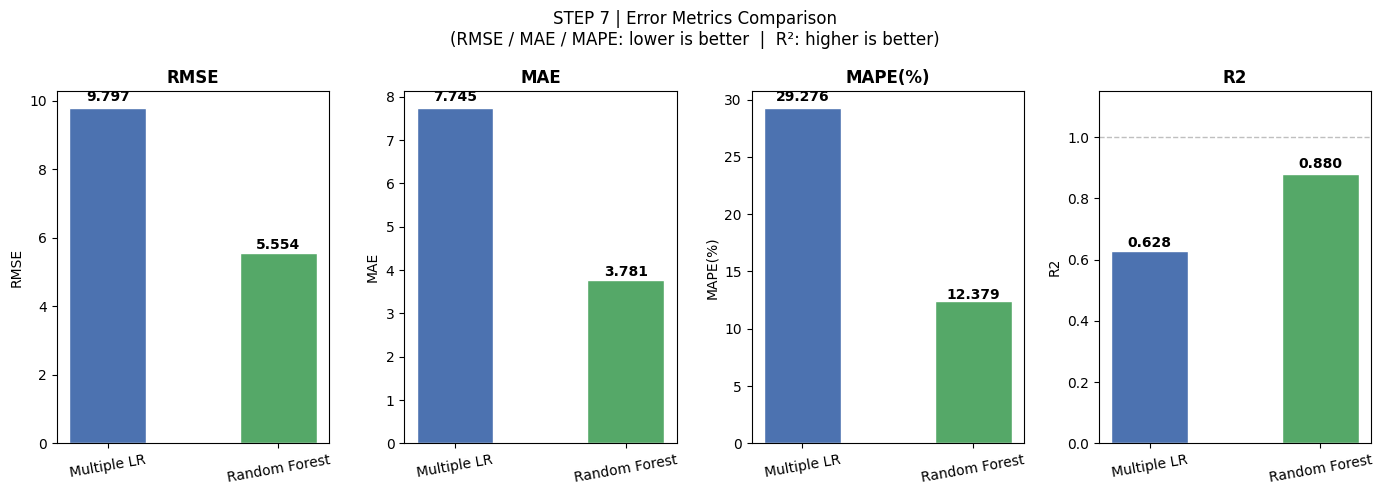

fig4 saved — Error metrics


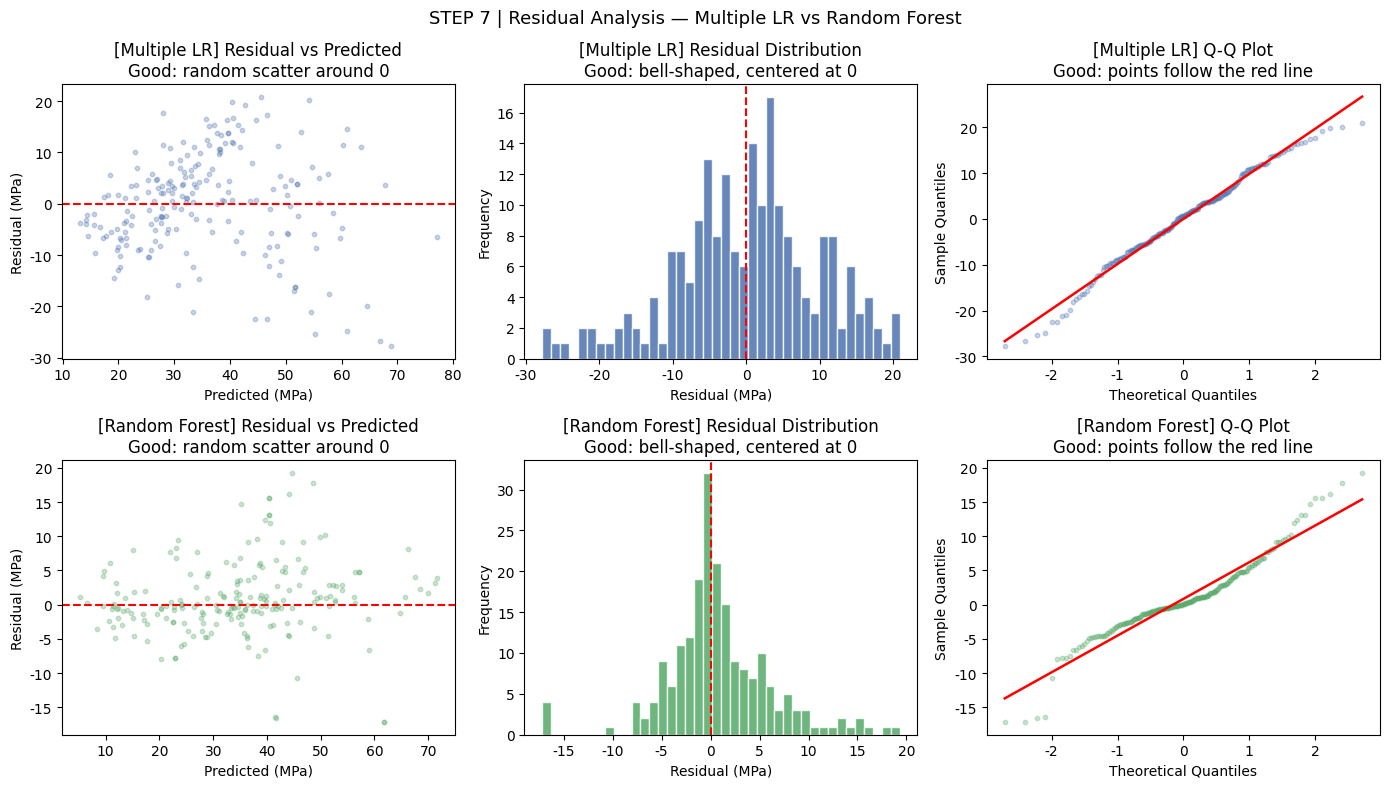

fig5 saved — Residual analysis


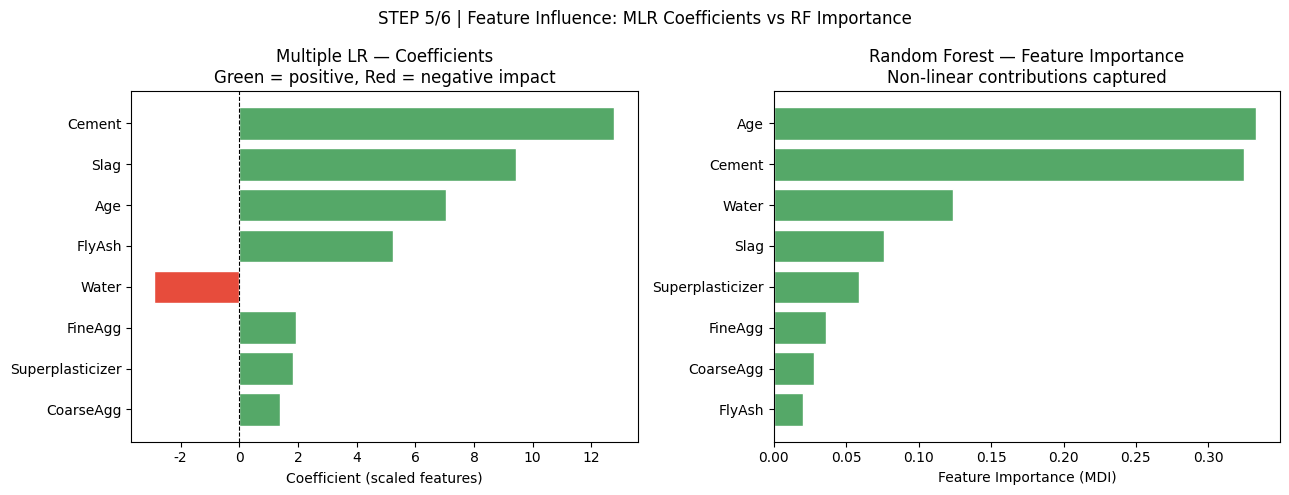

fig6 saved — Feature importance

SUMMARY
                 RMSE     MAE      R2  MAPE(%)
Model                                         
Multiple LR    9.7967  7.7454  0.6275  29.2763
Random Forest  5.5539  3.7813  0.8803  12.3793

Key Insight:
  Linear Regression R² = 0.628
  Random Forest     R² = 0.880
  → Concrete strength has STRONG NON-LINEAR relationships.
    RF captures interactions (e.g. Cement x Age) that LR cannot.

Top feature (RF) : Age  (importance=0.333)
Top feature (MLR): Cement  (coef=12.787)

All done — 6 figures saved.


In [12]:
# ══════════════════════════════════════════════════════════════
# STEP 8.  Visualization  (6 figures)
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8.  Visualization — 6 figures")
print("=" * 60)

CLR = '#4C72B0'   # Multiple LR  (blue)
CRF = '#55A868'   # Random Forest (green)

# ── Figure 1: Feature distributions + Strength ─────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flatten(), COLUMNS):
    color = '#E67E22' if col == 'Strength' else '#5DADE2'
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
plt.suptitle('STEP 2 | Feature Distributions\n'
             '(Slag, FlyAsh, Superplasticizer are zero-inflated)',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig1 saved — Feature distributions")

# ── Figure 2: Correlation heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df.corr()
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(COLUMNS)))
ax.set_yticks(range(len(COLUMNS)))
ax.set_xticklabels(COLUMNS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(COLUMNS, fontsize=9)
for i in range(len(COLUMNS)):
    for j in range(len(COLUMNS)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('STEP 2 | Correlation Matrix\n'
             'Cement & Age positively correlated; Water negatively correlated',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig2 saved — Correlation heatmap")

# ── Figure 3: Predicted vs Actual ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_pred, color) in zip(axes, [
        ('Multiple Linear Regression', y_pred_mlr, CLR),
        ('Random Forest',              y_pred_rf,  CRF)]):
    ax.scatter(y_test, y_pred, alpha=0.4, s=18, color=color)
    lo = min(float(y_test.min()), float(y_pred.min()))
    hi = max(float(y_test.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='Perfect Prediction')
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f'{name}\nR² = {r2:.4f}   RMSE = {rmse:.2f} MPa',
                 fontsize=11)
    ax.set_xlabel('Actual Strength (MPa)')
    ax.set_ylabel('Predicted Strength (MPa)')
    ax.legend(fontsize=9)

plt.suptitle('STEP 7 | Predicted vs Actual — MLR vs Random Forest',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig3_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig3 saved — Predicted vs Actual")

# ── Figure 4: Error metrics comparison ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE(%)', 'R2']):
    vals  = result_df[metric]
    colors = [CLR, CRF]
    bars  = ax.bar(vals.index, vals.values, color=colors, edgecolor='white',
                   width=0.45)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    if metric == 'R2':
        ax.set_ylim(0, 1.15)
        ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)

plt.suptitle('STEP 7 | Error Metrics Comparison\n'
             '(RMSE / MAE / MAPE: lower is better  |  R²: higher is better)',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig4_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig4 saved — Error metrics")

# ── Figure 5: Residual analysis ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
pairs = [
    ('Multiple LR',   y_pred_mlr, CLR),
    ('Random Forest', y_pred_rf,  CRF),
]
for row, (name, y_pred, col) in enumerate(pairs):
    resid = y_test.values - y_pred

    # (a) Residual vs Predicted
    ax = axes[row][0]
    ax.scatter(y_pred, resid, alpha=0.3, s=10, color=col)
    ax.axhline(0, color='red', ls='--', lw=1.5)
    ax.set_xlabel('Predicted (MPa)')
    ax.set_ylabel('Residual (MPa)')
    ax.set_title(f'[{name}] Residual vs Predicted\n'
                 'Good: random scatter around 0')

    # (b) Residual histogram
    ax = axes[row][1]
    ax.hist(resid, bins=40, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', ls='--', lw=1.5)
    ax.set_xlabel('Residual (MPa)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'[{name}] Residual Distribution\n'
                 'Good: bell-shaped, centered at 0')

    # (c) Q-Q plot
    ax = axes[row][2]
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=10, color=col)
    x_line = np.array([min(osm), max(osm)])
    ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.8)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'[{name}] Q-Q Plot\n'
                 'Good: points follow the red line')

plt.suptitle('STEP 7 | Residual Analysis — Multiple LR vs Random Forest',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig5_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig5 saved — Residual analysis")

# ── Figure 6: Feature importance comparison ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MLR: absolute coefficients (scaled → comparable)
ax = axes[0]
coef_abs = coef_df.copy()
coef_abs['AbsCoef'] = coef_abs['Coefficient'].abs()
coef_abs = coef_abs.sort_values('AbsCoef')
bar_colors = [CRF if v > 0 else '#E74C3C' for v in coef_abs['Coefficient']]
ax.barh(coef_abs['Feature'], coef_abs['Coefficient'],
        color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Multiple LR — Coefficients\n'
             'Green = positive, Red = negative impact')

# RF: MDI feature importance
ax = axes[1]
fi_sorted = fi.sort_values()
ax.barh(fi_sorted.index, fi_sorted.values, color=CRF, edgecolor='white')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Random Forest — Feature Importance\n'
             'Non-linear contributions captured')

plt.suptitle('STEP 5/6 | Feature Influence: MLR Coefficients vs RF Importance',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig6 saved — Feature importance")

# ── Final summary ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(result_df[['RMSE','MAE','R2','MAPE(%)']].round(4).to_string())
print(f"\nKey Insight:")
print(f"  Linear Regression R² = {result_df.loc['Multiple LR','R2']:.3f}")
print(f"  Random Forest     R² = {result_df.loc['Random Forest','R2']:.3f}")
print(f"  → Concrete strength has STRONG NON-LINEAR relationships.")
print(f"    RF captures interactions (e.g. Cement x Age) that LR cannot.")
print(f"\nTop feature (RF) : {fi.idxmax()}  (importance={fi.max():.3f})")
print(f"Top feature (MLR): {coef_df.iloc[0]['Feature']}  "
      f"(coef={coef_df.iloc[0]['Coefficient']:.3f})")
print("\nAll done — 6 figures saved.")